In [1]:
from importlib import reload
import sys
import subprocess

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

# Run the simualtion

In [4]:
MODEL_NAME = "System_LMO_exe"
EQUILIBRIUM_TIME = 20.0
# PARAMS = "../parameters/params_lmo_v1_mod_tes.txt"
PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
# PARAMS = "../parameters/params_lmo_v1_default.txt"
# PARAMS = "../parameters/params.txt"


In [18]:
# Step 1. a fast/coarse simulation to reach equilibrium
log = subprocess.run(
    [
        f"./{MODEL_NAME}",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-4",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_NAME}_res_init.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log.stderr, log.stdout


('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [13]:
reload(pymodelica)

<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

In [14]:
# Plot all C and G to check if the system is at equilibrium

filename_init = f'../build/{MODEL_NAME}_res_init.mat'
time_steps_init, data_init = pymodelica.load_om_mat(filename_init)

pymodelica.mod_svg("../System_LMO.svg", "temp_image.svg", data_init, system_name="System_LMO", width=1500, display=True)

In [19]:

# Step 2: Compile another simulation with fine resolution starting from the final values of Step 1
# Using -iif (Import Initial File) and -iit (Import Initial Time) to reset startTime = 0.0
log2 = subprocess.run(
    [
        f"./{MODEL_NAME}",
        f"-r={MODEL_NAME}_res_final.mat",
        f"-overrideFile={PARAMS}",
        "-s=dassl",
        "-w",
        "-startTime=0",
        "-stopTime=0.1",
        "-stepSize=1e-6",
        "-tolerance=1e-8",
        f"-iif={MODEL_NAME}_res_init.mat",
        f"-iit={EQUILIBRIUM_TIME}",
        "-lv=-LOG_STDOUT",
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log2.stderr, log2.stdout

('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [20]:
filename = f'../build/{MODEL_NAME}_res_final.mat'

time_steps, data = pymodelica.load_om_mat(filename)
print(data.keys())

dict_keys(['CL.v', 'L.i', 'c1.T', 'c10.T', 'c2.T', 'c3.T', 'c4.T', 'c5.T', 'c6.T', 'c7.T', 'c8.T', 'c9.T', 'der(CL.v)', 'der(L.i)', 'der(c1.T)', 'der(c10.T)', 'der(c2.T)', 'der(c3.T)', 'der(c4.T)', 'der(c5.T)', 'der(c6.T)', 'der(c7.T)', 'der(c8.T)', 'der(c9.T)', 'C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'CL.i', 'G1', 'G10', 'G11', 'G12', 'G13', 'G14', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'GND.p.i', 'GND.p.v', 'HeatSource.port.Q_flow', 'HeatSource1.port.Q_flow', 'L.v', 'RL.LossPower', 'RL.R_actual', 'RL.i', 'c1.P_Joule', 'c1.R', 'c1.cp', 'c1.heatPort.Q_flow', 'c1.v', 'c10.cp', 'c10.port.Q_flow', 'c2.cp', 'c2.port.Q_flow', 'c3.cp', 'c3.port.Q_flow', 'c4.cp', 'c4.port.Q_flow', 'c5.cp', 'c5.port.Q_flow', 'c6.cp', 'c6.port.Q_flow', 'c7.cp', 'c7.port.Q_flow', 'c8.cp', 'c8.port.Q_flow', 'c9.cp', 'c9.port.Q_flow', 'edep_film.y', 'edep_target.y', 'fixedTemperature.port.Q_flow', 'g1.Q_flow', 'g10.Q_flow', 'g11.Q_flow', 'g12.Q_flow', 'g13.Q_flow', 'g14.Q_flow', 'g2.Q

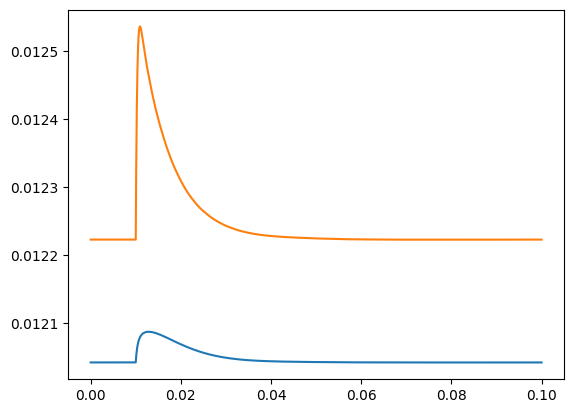

In [21]:
# plt.plot(time_steps, data['tes.i'])
plt.plot(time_steps, data['T1'])
plt.plot(time_steps, data['T2'])
# plt.plot(time_steps, data['T10'])

# Complex impedance

In [195]:
reload(pymodelica)

<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

In [ ]:
class TESModel:
    def __init__(self, linearized_model, config, f_min = 1, f_max = 100e3, points = 1000):
        """
        config: dict
            Dictionary containing the configuration parameters for the analysis. List of parameters:
            "L": Inductance value of the TES circuit in Henrys (H).
            "RL": Resistance value of the TES circuit in Ohms (Ω).
        """
        
        self.config = config
        self.model = pymodelica.load_linearized_model(linearized_model)
        self.frequencies = np.logspace(np.log10(f_min), np.log10(f_max), points)
        self.w = 2j*np.pi*self.frequencies

        
        
    def get_impedance(self):
        """
        Solver for complex impedance
        ---
        ---
        Z_model: array of complex float
            complex impedance
        """
        A = self.model["A"]
        
        Z_model = []
        for iw in self.w:
            N = - A + iw*np.eye(A.shape[0]) # Compute eigenvectors
            N_inv = np.linalg.inv(N) # Compute inverse of the eigenvectors      
            phi0 = np.zeros_like(self.model["x0"])  # Pulse to Absorber
            phi0[0] = 1/self.config["L"]

            res = N_inv.dot(phi0) #Dot the inverse of the eigenvector with the input pulse to get our coefficients

            Z_model.append(-1./res[0]-iw*self.config["L"])
        Z_model = np.array(Z_model)
        return Z_model
    
    @staticmethod
    def noise_phonon(K,T1,T2,n):
        """
        Phonon noise density, or say thermal fluctuation noise between 2 components. Defined as noise=sqrt( 2*kb*(G1*T1^2 + G2*T2^2) )
        Since G = nKT1^(n-1), nosie = sqrt( 2*kb*n*K*(T1^(n+1) + T2^(n+1)) )
        ---
        K: float
            conductance constant as defined in P = K*(T1^n - T2^n)
        T1,T2: float
            temperature of component 1 and 2
        n: float
            exponent of thermal conductance
        ---
        noise: float
            phonon noise
        """
        noise = np.sqrt(2.* 1.38e-23 * n * K (T1**(n+1) + T2**(n+1)))
        return noise
    
    
    
    def get_noise_LMO(self, simulation_results, TES_beta = 0, RL_temperature = None, noise_electronics = 0, noise_flicker_corner = 0, noise_flicker_gamma = 1):
        """
        Compute the noise density of the LMO system. This need to be hardcoded for each system. 
        ---
        noise: array of float
            noise density of the TES system
        """

        A = self.model["A"]
        x0 = self.model["x0"]
        nparams = len(x0)
        def S(iw):
            return np.linalg.inv(- A + iw*np.eye(A.shape[0]))
        
        ## 1. Thermal noise (passive + active)
        TES_R0 = simulation_results["c10.R"][-1]
        TES_T0 = simulation_results["c10.T"][-1]
        BIAS_RL = simulation_results["RL.R"][-1]
        BIAS_T = RL_temperature if RL_temperature is not None else TES_T0
        e_int = np.sqrt(4.*scipy.constants.k * TES_T0*TES_R0 * (1+2*TES_beta))              # Internal Johnson Noise
        e_ext = np.sqrt(4.*scipy.constants.k * BIAS_T*BIAS_RL)     # external Johnson Noise across shunt resistor        

        ## 2. Phonon noise
        p_TFNs_edges = {}
        for i in range(1,14):
            K =  simulation_results[f"g{i}.K"][-1]
            n =  simulation_results[f"g{i}.n"][-1]
            T1 =  simulation_results[f"g{i}.port_a.T"][-1]
            T2 =  simulation_results[f"g{i}.port_b.T"][-1]
            p_TFNs_edges[i] = self.noise_phonon(K,T1,T2,n)

        
        # Assemble the noise sources of each edges into a vector of source terms for the system of equations.
        #  ['L_i','c1_T','c10_T','c2_T','c3_T','c4_T','c5_T','c6_T','c7_T','c8_T','c9_T']
        
        p_TFNs_edges_vectors = {}
        for i in range(1,14):
            p_TFNs_edges_vectors[i] = np.zeros(nparams)
        i = 1
        p_TFNs_edges_vectors[i][1-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][2-1] = -p_TFNs_edges[i]
        i = 2
        p_TFNs_edges_vectors[i][2-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][3-1] = -p_TFNs_edges[i]
        i = 3
        p_TFNs_edges_vectors[i][2-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][3-1] = -p_TFNs_edges[i]
        i = 4
        p_TFNs_edges_vectors[i][4-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][10-1] = -p_TFNs_edges[i]
        i = 5
        p_TFNs_edges_vectors[i][4-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][5-1] = -p_TFNs_edges[i]
        i = 6
        p_TFNs_edges_vectors[i][10-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][5-1] = -p_TFNs_edges[i]
        i = 7
        p_TFNs_edges_vectors[i][10-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][6-1] = -p_TFNs_edges[i]
        i = 8
        p_TFNs_edges_vectors[i][6-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][7-1] = -p_TFNs_edges[i]
        i = 9
        p_TFNs_edges_vectors[i][7-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][8-1] = -p_TFNs_edges[i]
        i = 10
        p_TFNs_edges_vectors[i][8-1] = p_TFNs_edges[i]
        i = 11
        p_TFNs_edges_vectors[i][7-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][5-1] = -p_TFNs_edges[i]
        i = 12
        p_TFNs_edges_vectors[i][5-1] = p_TFNs_edges[i]
        p_TFNs_edges_vectors[i][9-1] = -p_TFNs_edges[i]
        i = 13
        p_TFNs_edges_vectors[i][9-1] = p_TFNs_edges[i]
        i = 14
        p_TFNs_edges_vectors[i][1-1] = -p_TFNs_edges[i]
        
        # Define the actual noise terms
        def noise_electronics():
            y = p['electronics_noise']
            return y
        def noise_one_over_f(w):
            y = p['one_over_f_noise']*(2.0*np.pi/w)**p['one_over_f_gamma']
            return y
          
        
        def noise_total_noise(w):
            noise = np.sqrt(noise_eint(w)**2+noise_eext(w)**2+noise_pau2te(w)**2+noise_ptem(w)**2+noise_psite(w)**2+noise_pag(w)**2+noise_paau1(w)**2+noise_pab(w)**2+noise_pulse(w)**2+noise_pgsi(w)**2+noise_pau1wb1(w)**2+noise_pwb1au2(w)**2+noise_psiau2(w)**2+noise_psim(w)**2+noise_pmwb2(w)**2+noise_pwb2b(w)**2 + noise_total_extra_electronic_noise(w)**2+noise_pgb(w)**2)
            return noise
        
        # Define the NEPs
        input_position = 3   # Now input in Absorber
        def NEP_eint(w):
            nep = np.abs(noise_eint(w)/S(w)[0,input_position])
            return nep


        def NEP_total_noise(w):
            NEP_total_squared = NEP_eint(w)**2+NEP_eext(w)**2+NEP_pau2te(w)**2+NEP_ptem(w)**2+NEP_psite(w)**2+NEP_pag(w)**2+\
                                NEP_paau1(w)**2+NEP_pab(w)**2+NEP_pulse(w)**2+NEP_pgsi(w)**2+NEP_pau1wb1(w)**2+NEP_pwb1au2(w)**2+\
                                NEP_psiau2(w)**2+NEP_psim(w)**2+NEP_pmwb2(w)**2+NEP_pwb2b(w)**2+NEP_total_extra_electronic_noise(w)**2+\
                                NEP_pgb(w)**2
            return np.sqrt(NEP_total_squared)
        
        def integrand(f):
            w = 2*np.pi*f
            NEP_total_squared = NEP_eint(w)**2+NEP_eext(w)**2+NEP_pau2te(w)**2+NEP_ptem(w)**2+NEP_psite(w)**2+NEP_pag(w)**2+NEP_paau1(w)**2+NEP_pab(w)**2+NEP_pulse(w)**2+NEP_pgsi(w)**2+NEP_pau1wb1(w)**2+NEP_pwb1au2(w)**2+NEP_psiau2(w)**2+NEP_psim(w)**2+NEP_pmwb2(w)**2+NEP_pwb2b(w)**2+NEP_total_extra_electronic_noise(w)**2+NEP_pgb(w)**2
            integrand = 1./NEP_total_squared
            return integrand
        
        # Integrate the NEP
        integral = quad(integrand,0,np.inf,epsabs=1e-20,epsrel=1e-10)
        # Compute the resolution of our detector
        resolution_en = 2.355*np.sqrt(4.*integral[0])**(-1.)
        # Convert the resolution to eV
        resolution_ev = resolution_en/p['eVtoJ']
        print("FWHM in eV = ",resolution_ev)
        print("Sigma in eV = ",resolution_ev/2.355)
        # Compute an ideal TES resolution
        ctot = cg + ca + cau1 + cwb1 + cau2 + csi + cte + cm + cwb2
        rough_resolution = np.sqrt(4*p['kb']*p['Tc']**2*ctot/p['alpha0']*np.sqrt(p['ntem']/2.)) # In sigma
        # Convert this to eV
        rough_resolution_ev = rough_resolution/p['eVtoJ']
        ideal_resolution = rough_resolution_ev
        print("Ideal Resolution in eV = ",rough_resolution_ev)
        
        frequencies = np.logspace(p['freq_min_exp'],p['freq_max_exp'],int(p['log_points']))
        
        list_noise = ['eint','eext','pau2te','ptem','psite','pag','paau1','pab','pulse','pgsi','pau1wb1','pwb1au2','psiau2','psim','pmwb2','pwb2b','pgb','total_extra_electronic_noise','total_noise']
        noise_dict = {}
        
        for name in list_noise:
            noise_dict[name] = {}
        
        for key in list_noise[0:-2]:
            exec( "noise_dict[key]['x'] = x_"+str(key))
            
        for key in noise_dict:
            noise_dict[key]['noise'] = []
            noise_dict[key]['NEP'] = []
            for f in frequencies:
                w = 2*np.pi*f
                func_temp = eval('noise_'+str(key))
                noise_dict[key]['noise'].append(func_temp(w))
                func_temp = eval('NEP_'+str(key))
                noise_dict[key]['NEP'].append(func_temp(w))
                
        resolution = {}
        resolution['Energy'] = resolution_ev/2.355
#        resolution['Timing'] = resolution_t
        resolution['IdealEnergy'] = ideal_resolution
        
        return noise_dict,frequencies,resolution

In [210]:
model = TESModel("../build/linearized_model.py", config={"L": 0.3e-6, "RL": 0.02}, f_min = 1, f_max = 100e3, points = 1000)

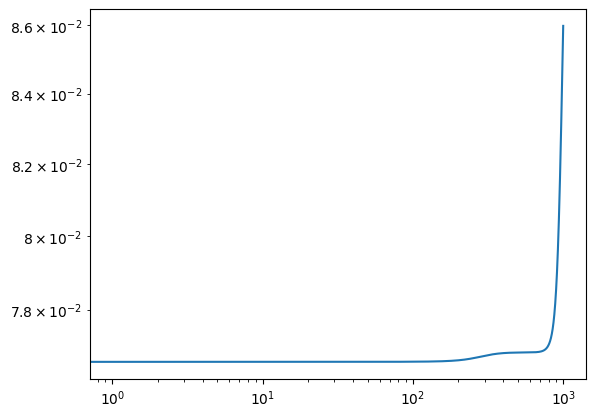

In [213]:
dvdi = model.get_impedance()
plt.loglog(np.abs(dvdi))

In [ ]:
    def Freq_Solver(self):
        """
        Frequency domain solver. Calculate the noise, NEP and resolution.
        ---
        ---
        noise_dict: dict
            dictionary contains all sources of noise
        frequencies: array
            frequency array coordinate with noise_dict
        resolution: dict
        """
            
